In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

### Úkol 1: Načtěte dataset ze souboru Synthetic dataset.csv. Identifikujte vstupní proměnnou X a cílovou proměnnou Y (podle názvů sloupců v CSV).

In [2]:
file_path = "Datasets/Synthetic_dataset.csv"
df = pd.read_csv(file_path)
print(df.head())

# Select features
X = df["X"].values.reshape(-1, 1)
y = df["Y"].values
# print(X)
# print(y)

          X          Y
0 -3.000000  33.652460
1 -2.979933  32.110669
2 -2.959866  32.589028
3 -2.939799  33.204325
4 -2.919732  30.107067


Úkol 2: Vytvořte bodový graf (scatterplot) Y = f(X). Osa x: vstupní proměnná, osa y: cílová proměnná. Uložte graf do formátu png. Vytvořte bodový graf (scatterplot) Y = f (X ). Osa x : vstupní proměnná, osa y : cílová proměnná. Uložte graf do formátu png.

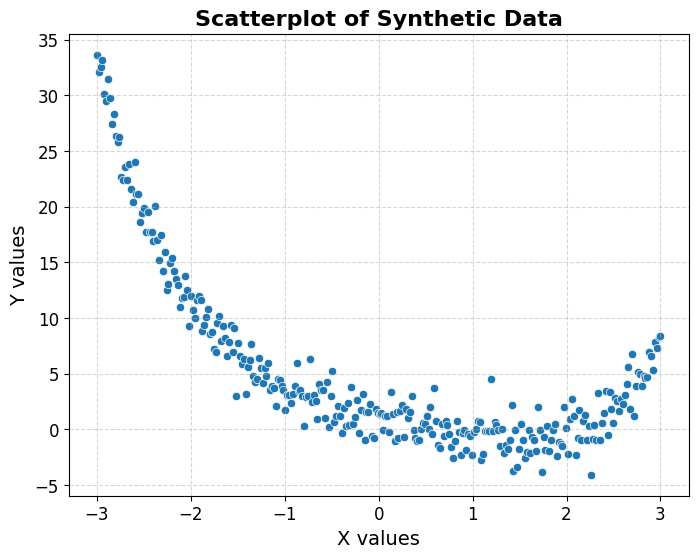

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

### 3. Natrénujte následující regresní modely:
- lineární regresi,
- polynomiální regresi pro stupně d ∈ {2, 3, 4, 5, 6, 7}.

Pro každý model vytvořte predikce ŷ na stejných datech (nebo na testovací množině, pokud provedete rozdělení).

In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_reg = lin_reg.predict(X_test)


mse_lin = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin_reg)
r2_lin = r2_score(y_test, y_pred_lin_reg)

# rows: different models, columns: different metrics
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MSE": [mse_lin],
    "RMSE": [rmse_lin],
    "MAE": [mae_lin],
    "R2 Score": [r2_lin]
})
# print(results)


degrees = [2, 3, 4, 5, 6, 7]
y_poly_pred = {}
poly_regs = {}


for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly_train, y_train)
    poly_regs[degree] = poly_reg

    y_poly_pred[degree] = poly_reg.predict(X_poly_test)
    mse_poly = mean_squared_error(y_test, y_poly_pred[degree])
    rmse_poly = np.sqrt(mse_poly)
    mae_poly = mean_absolute_error(y_test, y_poly_pred[degree])
    r2_poly = r2_score(y_test, y_poly_pred[degree])
    
    new_row = pd.DataFrame({
        "Model": [f"Polynomial Regression (degree={degree})"],
        "MSE": [mse_poly],
        "RMSE": [rmse_poly],
        "MAE": [mae_poly],
        "R2 Score": [r2_poly]
    })
    results = pd.concat([results, new_row], ignore_index=True)


4. Vypočıtejte pro každý model následující metriky kvality:
    - MSE, RMSE, MAE, R^2
Výsledky uložte do tabulky (např. pandas DataFrame) a určete nejlepší polynomiální stupenň na základě metrik.

In [5]:
print(results.sort_values(by="MSE", ascending=True))

                              Model        MSE      RMSE       MAE  R2 Score
3  Polynomial Regression (degree=4)   1.320681  1.149209  0.880793  0.978301
4  Polynomial Regression (degree=5)   1.361519  1.166841  0.886694  0.977630
5  Polynomial Regression (degree=6)   1.390499  1.179194  0.910980  0.977154
6  Polynomial Regression (degree=7)   1.409376  1.187171  0.913219  0.976843
2  Polynomial Regression (degree=3)   3.203969  1.789963  1.488703  0.947358
1  Polynomial Regression (degree=2)   4.372322  2.091010  1.685629  0.928161
0                 Linear Regression  28.991143  5.384342  4.112627  0.523665


## Nejlepší polynomiální stupeň na základě metrik je 4.

### 5. Vytvořte jeden společný graf (1 okno), ve kterém zobrazíte:
- scatterplot dat,
- regresní přímku lineární regrese,
- regresní křivky polynomiálních regresí pro d = 2, . . . , 7.

Každou regresní křivku vykreslete jinou barvou a přidejte legendu. Uložte graf do formátu png.

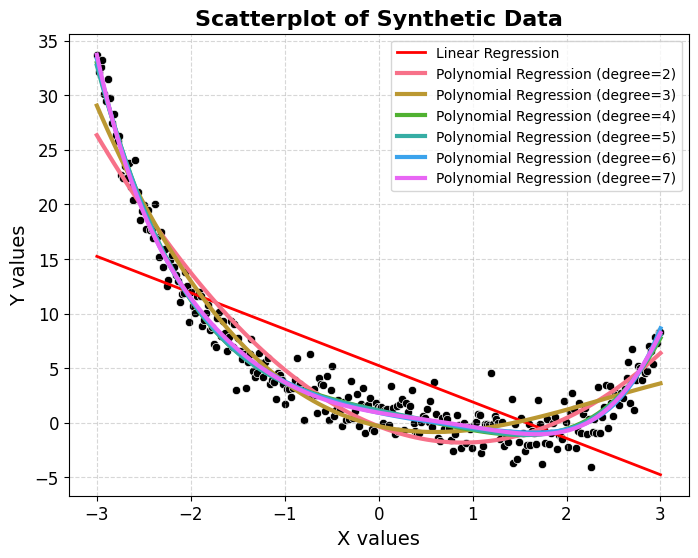

{2: array([-1.76971573,  2.02294152, -0.49696756, 23.79468961, -0.70320766,
       -1.07232479, -1.82509744,  3.59546371, 24.9134061 , -1.552013  ,
       -0.45941607, 12.23457643, -1.40453424, 14.80190544, -1.71624608,
       -1.29116053,  4.88510683, -1.61678366, -0.23280657, -1.19040617,
        8.25941409,  3.09824213,  0.41538061,  0.49799119,  4.25060519,
       15.4773522 ,  3.79993238,  5.76173475, -0.79355428, -0.39473323,
       21.62896757, -1.14602861, 17.58436731, 19.81239465, -1.50446215,
        2.39722911, 24.3510599 ,  6.28370044, 14.57974448,  9.14612219,
        5.82338653,  8.6096154 ,  4.46696157, 11.62635869,  8.43376776,
       11.03158675, -0.64450073, -0.9230956 ,  3.34386497, -0.81613959,
       -1.67679223,  0.05525806, -0.3285564 ,  8.78695702,  6.06589588,
        3.4176426 ,  5.23055035,  5.97533052, -1.82387662, 19.55886014]), 3: array([-5.60717663e-01,  2.00944136e+00, -4.09712459e-01,  2.55797292e+01,
        4.50956480e-01,  1.66913437e-01, -7.03323056

In [22]:
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y", color='black')
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency

# Plot linear regression (using X_test is not ideal for a line plot as points are unordered, better to use grid)
lin_reg_pred_grid = lin_reg.predict(X_grid)
plt.plot(X_grid, lin_reg_pred_grid, color="red", linewidth=2, label="Linear Regression")

colors = sns.color_palette("husl", len(degrees))
for i, degree in enumerate(degrees):
    # Create polynomial features for the specific degree
    poly_temp = PolynomialFeatures(degree=degree)
    X_poly_grid = poly_temp.fit_transform(X_grid)
    
    # Predict
    y_poly_grid = poly_regs[degree].predict(X_poly_grid)
    plt.plot(X_grid, y_poly_grid, color=colors[i], linewidth=3, label=f"Polynomial Regression (degree={degree})")

plt.legend()


plt.show()

print(y_poly_pred)